# UPA - 3.projekt

## 1.časť

In [2]:
#Modules import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [3]:
# Load the dataframe
df = pd.read_csv("data.csv")
df.head()

,url,name,price,quantity_box,quantity_carton,color,material,dipping
0,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,69.43,12.0,72.0,žlutá,bavlna,NaN
1,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®PERRY UNI,15.67,NaN,NaN,NaN,NaN,NaN
2,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®RANDY,43.44,12.0,120.0,bílá,polyester,latex
3,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,60.50,12.0,72.0,žlutá,bavlna,NaN
4,https://www.ardon.cz/zimni-rukavice-ardon-r-ho...,Zimní rukavice ARDON®HOBBY REFLEX WINTER,104.15,12.0,120.0,reflexní,kůže,NaN


# Explorativná analýza

Pre zvolenú datovú sadu z prvého projektu najskôr prevedieme exploratívnu analýzu.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              150 non-null    object 
 1   name             150 non-null    object 
 2   price            150 non-null    float64
 3   quantity_box     127 non-null    float64
 4   quantity_carton  127 non-null    float64
 5   color            140 non-null    object 
 6   material         142 non-null    object 
 7   dipping          83 non-null     object 
dtypes: float64(3), object(5)
memory usage: 9.5+ KB


Datová sada obsahuje 7 následujúcich atribútov:
url: unikátny identifikátor webovej stránky každej rukavice (kategorický)
name: Názov rukavíc (kategorický)
price: Cena rukavíc (kvantitatívny)
quantity_box: Počet rukavíc v balení (kvantitatívny)
quantity_carton Počet rukavíc v kartóne (kvantitatívny)
color: Farba rukavíc (kategorický)
material: Materiál z ktorého sú rukavice vyrobené (kategorický)
dipping: Máčanie rukavíc (kategorický)

Celkovo datová sada obsahuje 3 kvantitatívne a 5 kategorických atribútov.

V datovej sade sa nachádzajú aj chýbajúce hodnoty, kde najviac ich chýba v máčaní (dipping).

In [5]:
print(df.describe())

# Additional details: range, unique values, etc.
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\nColumn: {column}")
    print(f"Range: {df[column].min()} - {df[column].max()}")
    print(f"Unique values: {df[column].nunique()}")

             price  quantity_box  quantity_carton
count   150.000000    127.000000       127.000000
mean    143.714333     11.850394       132.881890
std     146.519208      1.031863        96.690524
min       5.960000      1.000000        60.000000
25%      43.937500     12.000000        72.000000
50%     108.005000     12.000000       120.000000
75%     195.245000     12.000000       144.000000
max    1188.190000     12.000000       600.000000

Column: price
Range: 5.96 - 1188.19
Unique values: 136

Column: quantity_box
Range: 1.0 - 12.0
Unique values: 3

Column: quantity_carton
Range: 60.0 - 600.0
Unique values: 9


Analyzovali sme kvantitatívne atribúty v dátovej sade s cieľom získať prehľad o ich štatistických vlastnostiach.

Atribúty ceny vykazujú variabilitu pravdepodobne v dôsledku prítomnosti odľahlých hodnôt. Atribút množstva v krabici vykazuje značne obmedzený počet unikátných hodnôt, tento fakt môžeme vidieť aj v kvantiloch, kedy obsahujú iba maximálnu hodnotu. Atribút množstva v kártóne má lepšiu variabilitu, avšak počet unikátnych hodnôt je tiež nízky.

Chýbajúce hodnoty pre počty sú rovnaké, kde obom atribútom chýba 23 hodnôt. 

In [6]:
# Check unique and most frequent values in categorical columns
for column in df.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {column}")
    print(f"Unique values: {df[column].nunique()}")
    print("Most frequent values:")
    print(df[column].value_counts().head(5))


Column: url
Unique values: 150
Most frequent values:
url
https://www.ardon.cz/kombinovane-rukavice-ardon-r-elton-s-prodejni-etiketou    1
https://www.ardon.cz/atg-r-macene-rukavice-maxidry-r-56-425                    1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-305          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-504          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-505          1
Name: count, dtype: int64

Column: name
Unique values: 147
Most frequent values:
name
Kombinované rukavice ARDON®ELTON                 2
Svářečské rukavice ARDON®COY                     2
Máčené rukavice ARDON®PERRY UNI                  2
Zimní rukavice ARDON®Winfine                     1
ATG® protiřezné rukavice MaxiCut® Oil™ 44-305    1
Name: count, dtype: int64

Column: color
Unique values: 22
Most frequent values:
color
modrá     28
šedá      25
zelená    19
bílá      15
žlutá     12
Name: count, dtype: int64

Column: material


Teraz zanalyzujeme kategorické premenné.

Atribút url má všetky hodnoty unikátne, čo potvrdzuje, že slúži ako jednoznačný identifikátor každého produktu v dátovej sade.
Atribút názvu obsahuje tri duplikátne hodnoty, ktoré predstavujú rovnaké produkty. Po bližšej analýze sme zistili, že tieto produkty majú niektoré atribúty, ako napríklad cena, rozdielne, čo môže naznačovať odlišné varianty alebo rôzne balenia toho istého produktu.
Ostatné atribúty majú dobrú variabilitu s dostatočným počtom unikátnych hodnôt.

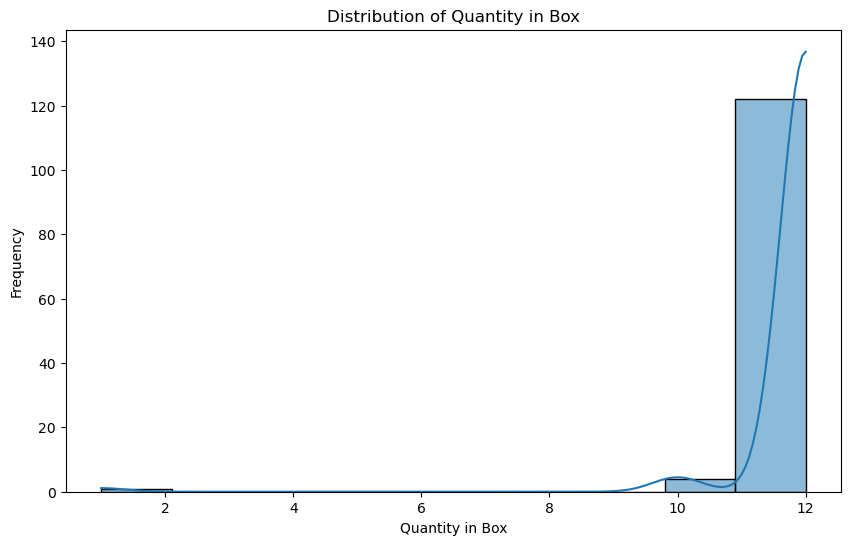

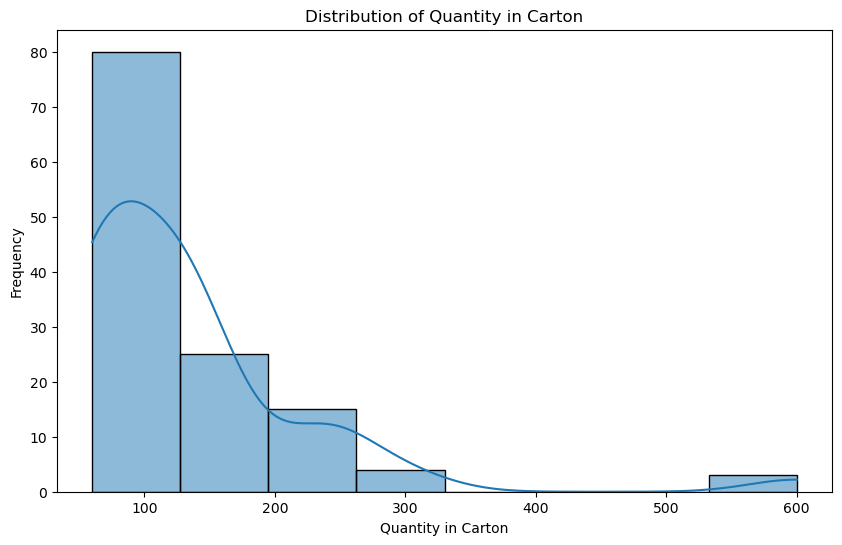

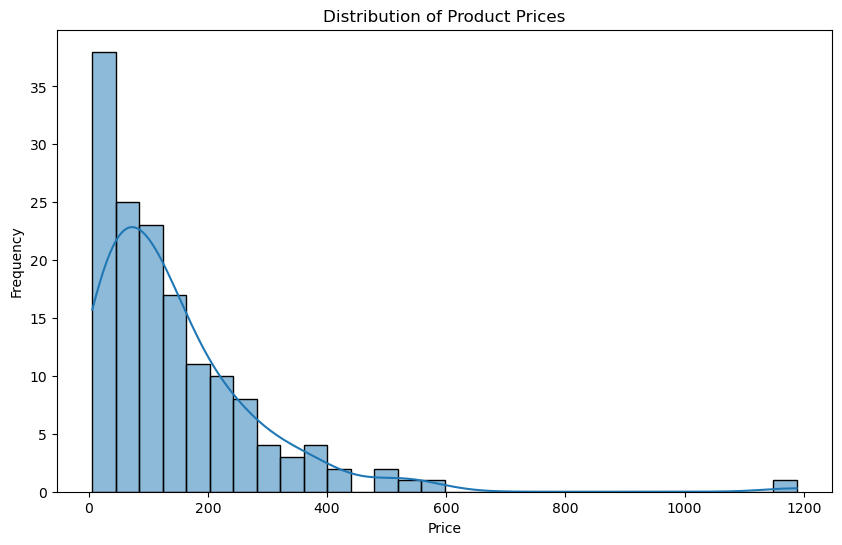

In [7]:
# Histogram graphs
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_box'], kde=True, bins=10)
plt.title('Distribution of Quantity in Box')
plt.xlabel('Quantity in Box')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_carton'], kde=True, bins=8)
plt.title('Distribution of Quantity in Carton')
plt.xlabel('Quantity in Carton')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Grafy histogramu nám vizualizujú distribúciu dát, pričom ich hodnoty zodpovedajú našim úvahám pri štatistickej analýze.

Graf počtu rukavíc v krabici ukazuje veľmi nízku variabilitu hodnôt, pričom väčšina vzoriek dosahuje maximálnu hodnotu (12 rukavíc v krabici). Zvyšné hodnoty mimo tohto rozsahu sú extrémne zriedkavé a takmer nevýznamné.

Graf počtu rukavíc v kartóne má väčšiu variabilitu ako môžeme vidieť. Väčšina dát sa koncentruje v rozmedzí 100–300 rukavíc na kartón, pričom zopár vzoriek dosahuje hodnoty až okolo 600. Tento graf tiež vykazuje prítomnosť vyšších hodnôt, ktoré by mohli byť považované za potenciálne outliery.

Graf ceny dosahuje vysokú variabilitu a má väčšie rozmedzie hodnôt, približne do ceny 600. Rovnako zopár vzorkov dosahuje hodnoty v rozmedzí 1100-1200. Tieto hodnoty sa nám pravdepodobne v nasledujúcich grafoch vyobrazia ako outliery.

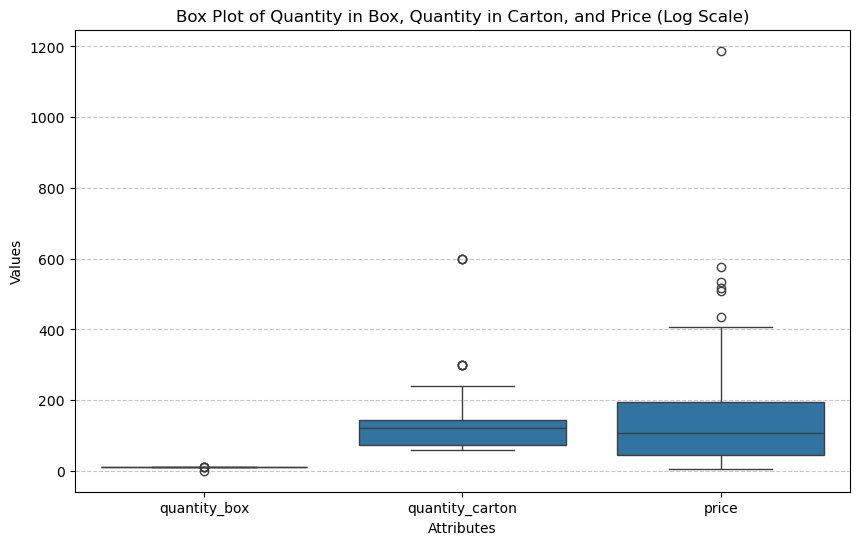

In [32]:
df_melted = df[['quantity_box', 'quantity_carton', 'price']].melt(var_name='Attribute', value_name='Value')

# Create a box plot with a log scale on the y-axis
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attribute', y='Value', data=df_melted)

# Set the title and labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Box Plot of Quantity in Box, Quantity in Carton, and Price (Log Scale)')
plt.xlabel('Attributes')
plt.ylabel('Values')

plt.show()

Boxplot graf oproti obyčajnému histogramu poskytuje detailnejší pohľad na dáta tým, že umožňuje vizualizáciu outlierov, mediánu a rozsahu medzi prvým a tretím kvartilom.

Atribút počtu rukavíc v krabici vykazuje, že skoro všetky dáta majú jednu zhodnú hodnotu bez viditeľnej variability. To naznačuje konštantnosť tohoto atribútu.

Atribút počtu rukavíc v kartóne vykazuje vyššiu variabilitu v porovnaní s predchádzajúcim atribútom. "Krabica" ukazuje rozptyl medzi prvým a tretím kvartilom, pričom odľahlé hodnoty (outliery) sú jasne zobrazené ako body nad rozsahom, ako bolo diskutované v predchádzajúcom grafe.

Atribút ceny vykazuje najväčší rozptyl hodnôt. Vidíme najvyšší počet outlierov, hlavne v intervale 600–1200, čo naznačuje veľkú medzeru medzi bežnými hodnotami a extrémne vysokými cenami.

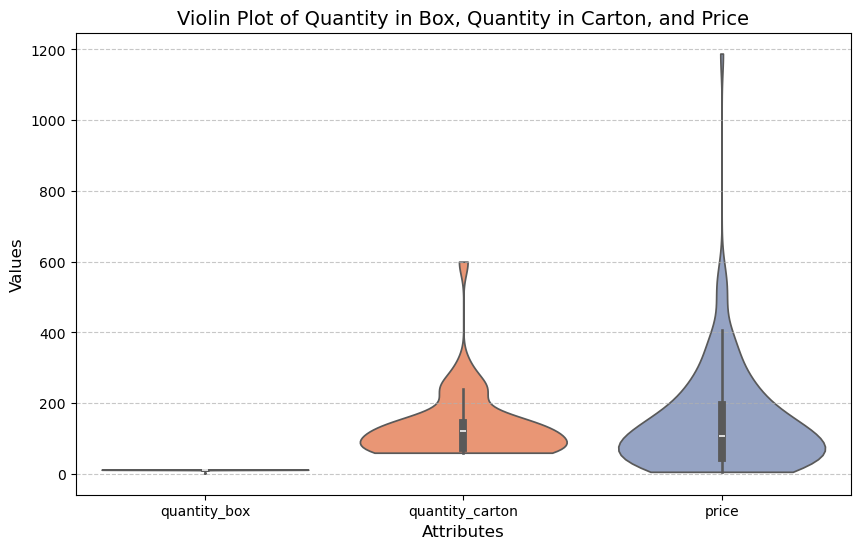

In [33]:
df_melted = df[['quantity_box', 'quantity_carton', 'price']].melt(var_name='Attribute', value_name='Value')

plt.figure(figsize=(10, 6))

sns.violinplot(
    x='Attribute', 
    y='Value', 
    hue='Attribute',
    data=df_melted, 
    palette='Set2',  # For nice visual colors than default
    cut=0            # Prevent violins from extending beyond data range
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Violin Plot of Quantity in Box, Quantity in Carton, and Price', fontsize=14)
plt.xlabel('Attributes', fontsize=12)
plt.ylabel('Values', fontsize=12)

# Display the plot
plt.show()

Na husľovom grafe môžeme vidieť distribúciu rovnakých dát ako v krabicovom. 

Atribút počtu rukavíc v krabici vykazuje nízku variabilitu a znovu v ňom dominuje jedna hodnota.

Atribút počtu rukavíc v kartóne pokrýva väčší rozsah hodnôt. Tvar huslí zdôrazňuje koncentráciu hodnôt medzi hodntotou 50 až 150, pričom niektoré dosahujú hodnoty 600.

Atribút ceny vykazuje najväčšiu variabilitu, kde dáta sú najviac koncentrované okolo hodnoty 100, pričom počet dát klesá s rastúcou sa cenou. Zopár hodnôt dosahuje hodnoty 1200.

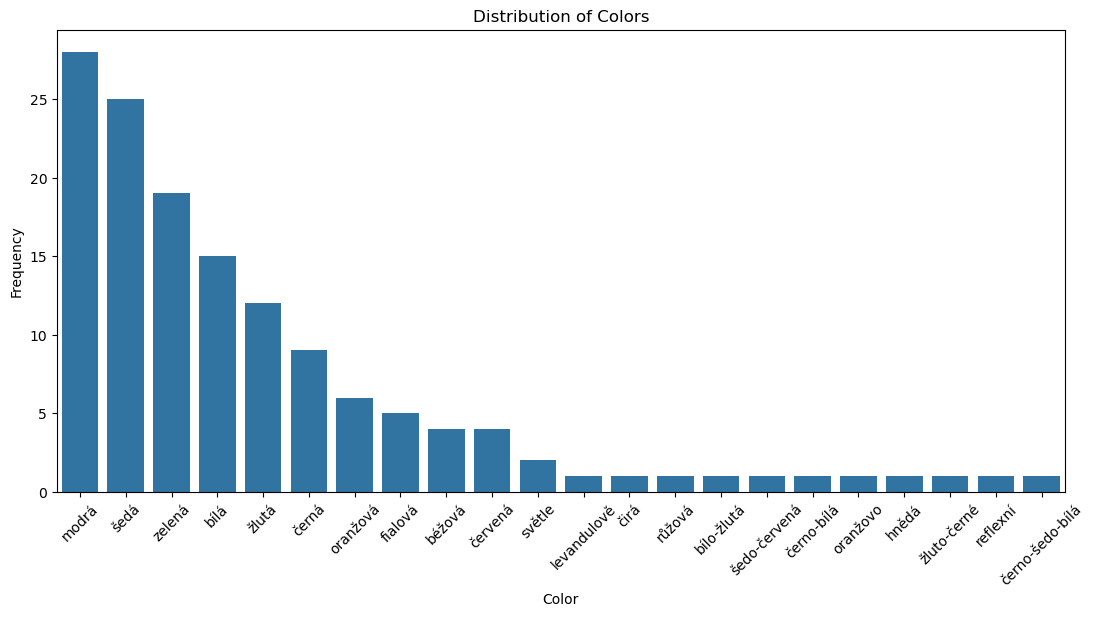

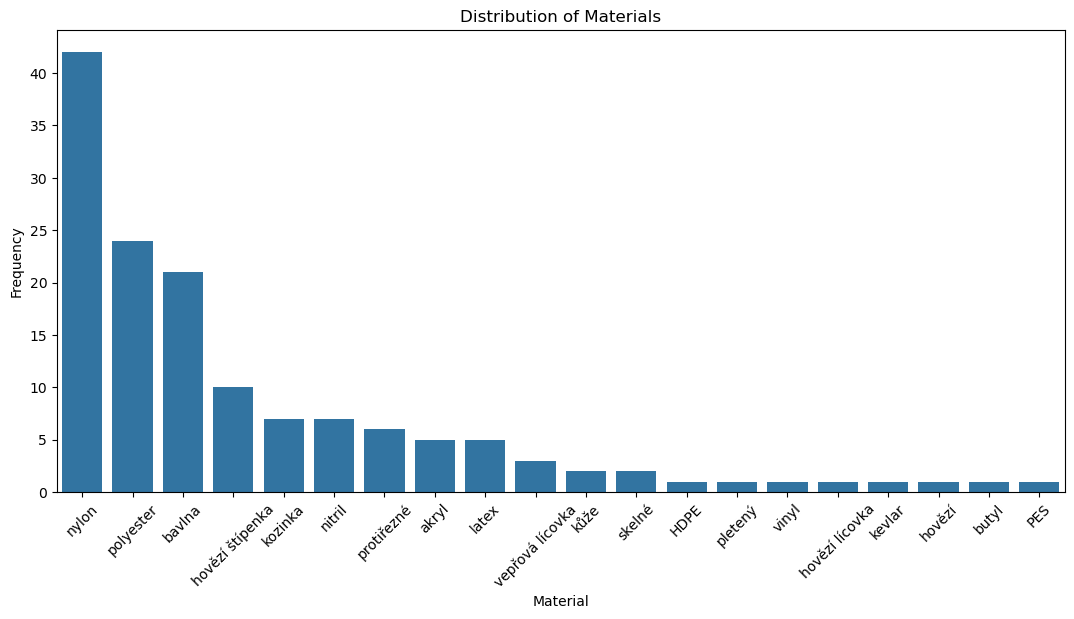

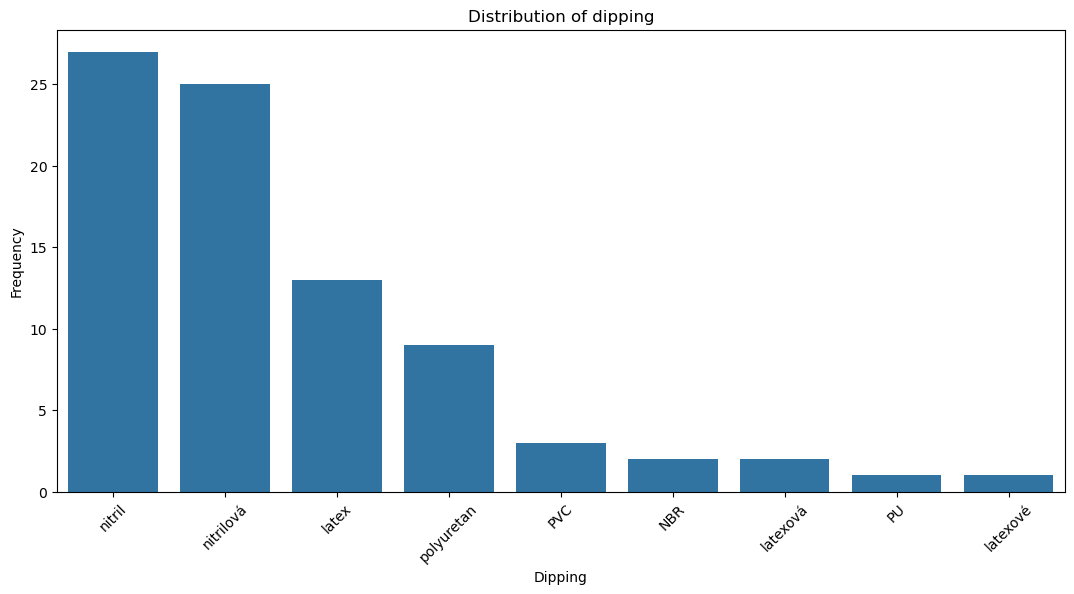

In [89]:
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='color', order=df['color'].value_counts().index)
plt.title('Distribution of Colors')
plt.xlabel('Color')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for the 'material' column
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='material', order=df['material'].value_counts().index)
plt.title('Distribution of Materials')
plt.xlabel('Material')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='dipping', order=df['dipping'].value_counts().index)
plt.title('Distribution of dipping')
plt.xlabel('Dipping')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Na histogramoch môžeme vidieť distribúciu farby, materiálu a máčania.

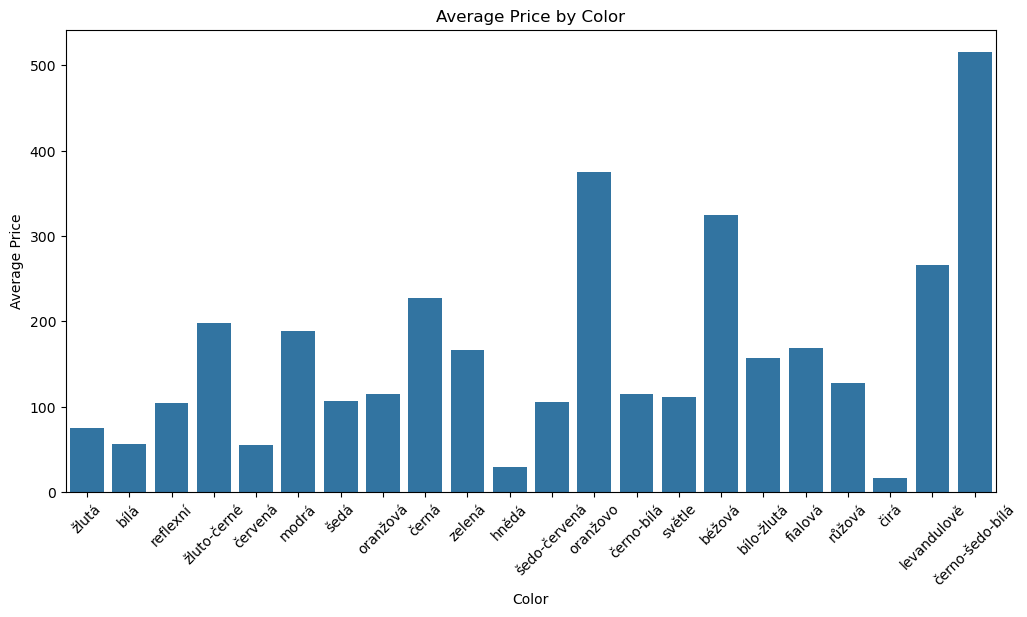

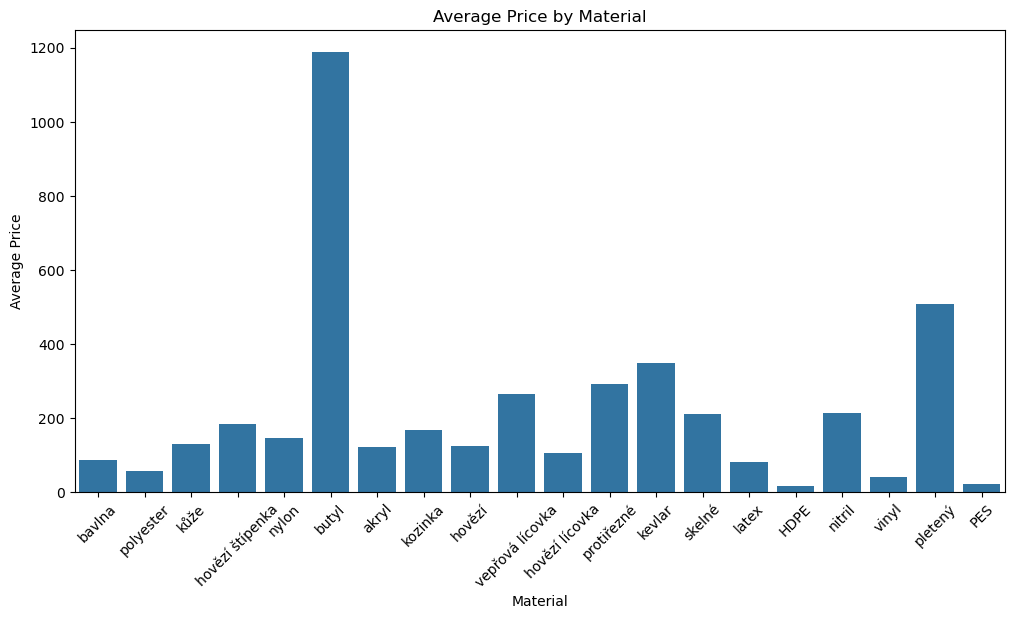

In [91]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='color', y='price', estimator='mean', errorbar=None)
plt.title('Average Price by Color')
plt.xlabel('Color')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='material', y='price', estimator='mean', errorbar=None)
plt.title('Average Price by Material')
plt.xlabel('Material')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

Na prvom grafe môžeme vidieť závislosť medzi cenou a farbou. Na druhom grafe závislosť medzi.

Z podstaty môžeme vidieť, že prvý graf nemá v sebe nejakú súvislosť medzi farbami. Pre niektoré farby síce môžeme vidieť, že je vyššia cena, avšak tento jav by sa pravdepodobne vyeliminoval, keby sme mali obshiahlejšiu datovú sadu.

Druhý graf obsahuje zmysluplnejšie hodnoty, kde môžeme vidieť, že cena sa odvíja od druhu materiálu.

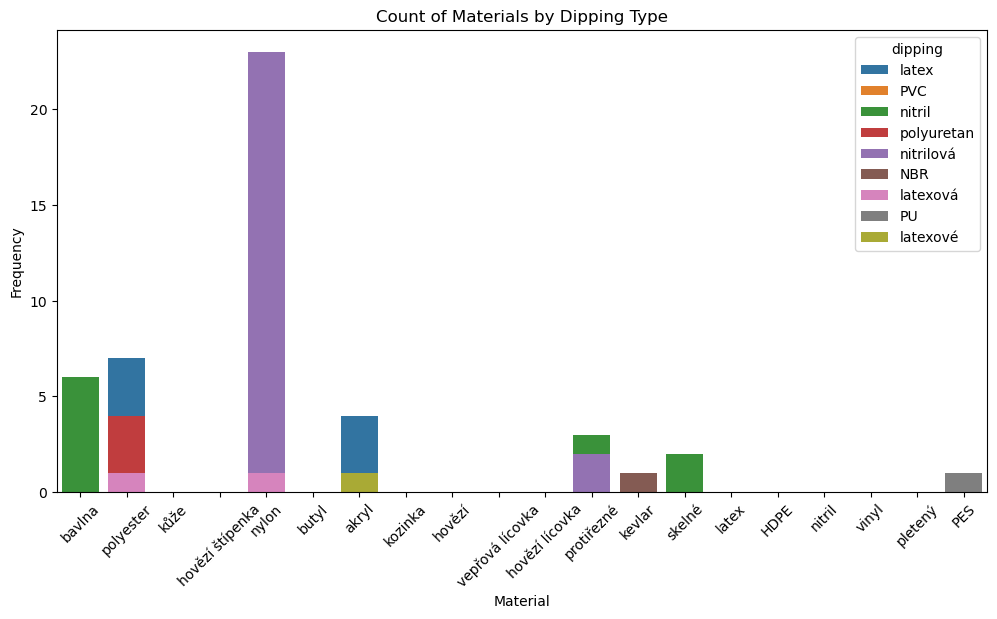

In [86]:
# Neviem ci zmyslu plny graf
# Stacked bar chart for 'material' and 'dipping'
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='material', hue='dipping')
plt.title('Count of Materials by Dipping Type')
plt.xlabel('Material')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

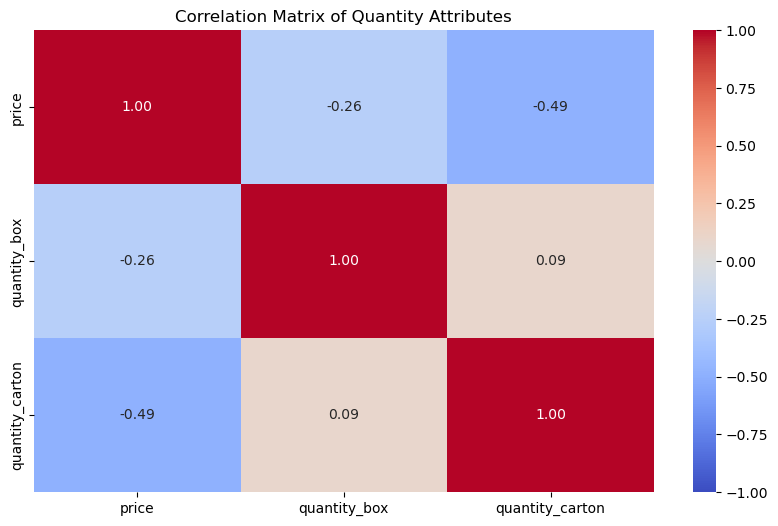

In [50]:
# TODO: Pridat aj kategoricke atributy

numeric_columns = df.select_dtypes(include=[np.number]).columns 
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Quantity Attributes')
plt.show()